In [50]:
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Set professional style for all plots
plt.style.use('seaborn-v0_8')  # Use a clean style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Define consistent color palettes
colors_age = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green for 0-19, 20-64, 65+
colors_tfr = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red for TFRs
colors_change = ['#d62728', '#2ca02c']  # Red for decrease, Green for increase


In [51]:
data = Path("data")

In [52]:
datafiler = os.listdir(data)
datafiler.sort()
datafiler

['.ipynb_checkpoints',
 'barnetallsfordeling.csv',
 'befolkning.csv',
 'befolkningsutvikling_2023_2038_1_5.csv',
 'befolkningsutvikling_2023_2038_2_1.csv',
 'befolkningsutvikling_2023_2058_1_1.csv',
 'befolkningsutvikling_2023_2058_1_5.csv',
 'befolkningsutvikling_2023_2058_2_1.csv',
 'befolkningsutvikling_2023_2063_1_5.csv',
 'befolkningsutvikling_2023_2073_1_66.csv',
 'befolkningsutvikling_2023_2123_1_5.csv',
 'befolkningsutvikling_2038_2053_2_1.csv',
 'befolkningsutvikling_2038_2058_2_1.csv',
 'befolkningsutvikling_2038_2078_2_1.csv',
 'befolkningsutvikling_2063_2113_1_1.csv',
 'befolkningsutvikling_2063_2113_1_5.csv',
 'befolkningsutvikling_2063_2113_2_1.csv',
 'popfordeling_2023-2038_tfr1_5.csv',
 'popfordeling_2023-2058_tfr1_1.csv',
 'popfordeling_2023-2058_tfr1_5.csv',
 'popfordeling_2023-2058_tfr2_1.csv',
 'popfordeling_2023-2063_tfr1_5.csv',
 'popfordeling_2023-2073_tfr1_66.csv',
 'popfordeling_2023-2123_tfr1_5.csv',
 'popfordeling_2038-2053_tfr2_1.csv',
 'popfordeling_2038-20

In [53]:
aktuelle_aar = 2058
aar = 2025
alder = 27
print(f"I året {aktuelle_aar} er jeg {aktuelle_aar - aar + alder} år gammel")

I året 2058 er jeg 60 år gammel


In [54]:
befolkning_23_63 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_5.csv")#.iloc[:,1:]
befolkning_23_63.tail(5)

,år,pop_1.5
31,2054,5553691
32,2055,5540264
33,2056,5524199
34,2057,5505572
35,2058,5484465


In [55]:
befolkning_63_23_1_5 = pd.read_csv(data / f"befolkningsutvikling_2023_2073_1_66.csv")#.iloc[:,1:]
befolkning_63_23_2_1 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_2_1.csv")#.iloc[:,1:]
befolkning_63_23_1_1 = pd.read_csv(data / f"befolkningsutvikling_2023_{aktuelle_aar}_1_1.csv")#.iloc[:,1:]

befolkning_63_23_1_5.head(5)
befolkning = befolkning_63_23_1_5.merge(befolkning_63_23_2_1, on ="år", how="left").merge(befolkning_63_23_1_1, on ="år", how="left").iloc[0:35, :]

In [56]:
befolkning_til_nå = pd.read_csv("data/befolkning.csv").iloc[:-1,]
befolkning_til_nå.head()

,år,pop
0,1986,4159187
1,1987,4175521
2,1988,4198289
3,1989,4220686
4,1990,4233116


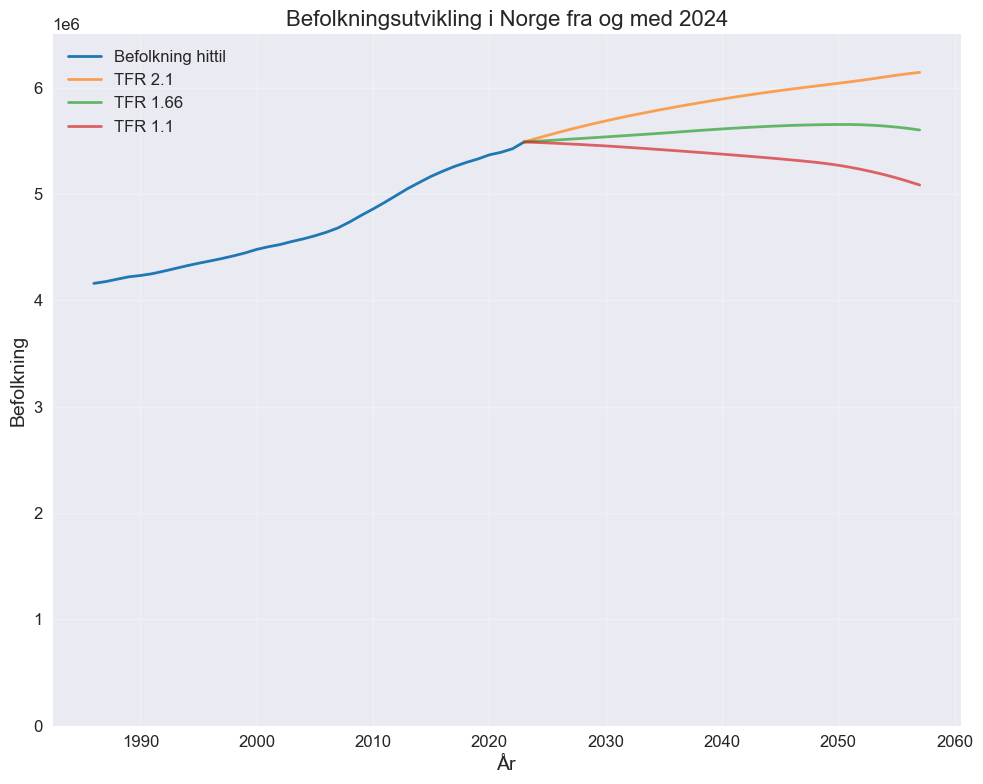

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(befolkning_til_nå.år, befolkning_til_nå["pop"], label='Befolkning hittil', color=colors_tfr[0], linewidth=2)
ax.plot(befolkning.år, befolkning["pop_2.1"], color=colors_tfr[1], alpha=0.7, linewidth=2, label='TFR 2.1')
ax.plot(befolkning.år, befolkning["pop_1.66"], color=colors_tfr[2], alpha=0.7, linewidth=2, label='TFR 1.66')
ax.plot(befolkning.år, befolkning["pop_1.1"], color=colors_tfr[3], alpha=0.7, linewidth=2, label='TFR 1.1')

ax.set_ylim(0, 65e5)
ax.set_ylabel('Befolkning')
ax.set_xlabel('År')
ax.set_title('Befolkningsutvikling i Norge fra og med 2024')
ax.legend()

plt.tight_layout()


In [58]:
befolkning["pop_2023"] = befolkning_til_nå.loc[lambda x: x.år == 2023]["pop"].values[0]

In [59]:
befolkning = befolkning.assign(
    pop_1_66_endring = lambda x: x["pop_1.66"] - x["pop_2023"],
    pop_2_endring = lambda x: x["pop_2.1"] - x["pop_2023"],
    pop_1_1_endring = lambda x: x["pop_1.1"] - x["pop_2023"],
)
befolkning

,år,pop_1.66,pop_2.1,pop_1.1,pop_2023,pop_1_66_endring,pop_2_endring,pop_1_1_endring
0,2023,5488984,5488984.0,5488984.0,5488984,0,0.0,0.0
1,2024,5495356,5520436.0,5484682.0,5488984,6372,31452.0,-4302.0
2,2025,5501882,5550894.0,5480111.0,5488984,12898,61910.0,-8873.0
3,2026,5508749,5580271.0,5474995.0,5488984,19765,91287.0,-13989.0
4,2027,5515554,5608620.0,5469617.0,5488984,26570,119636.0,-19367.0
5,2028,5522497,5635751.0,5464000.0,5488984,33513,146767.0,-24984.0
6,2029,5529515,5661724.0,5457967.0,5488984,40531,172740.0,-31017.0
7,2030,5536478,5686663.0,5451602.0,5488984,47494,197679.0,-37382.0
8,2031,5543531,5710724.0,5444821.0,5488984,54547,221740.0,-44163.0
9,2032,5550671,5733794.0,5437630.0,5488984,61687,244810.0,-51354.0


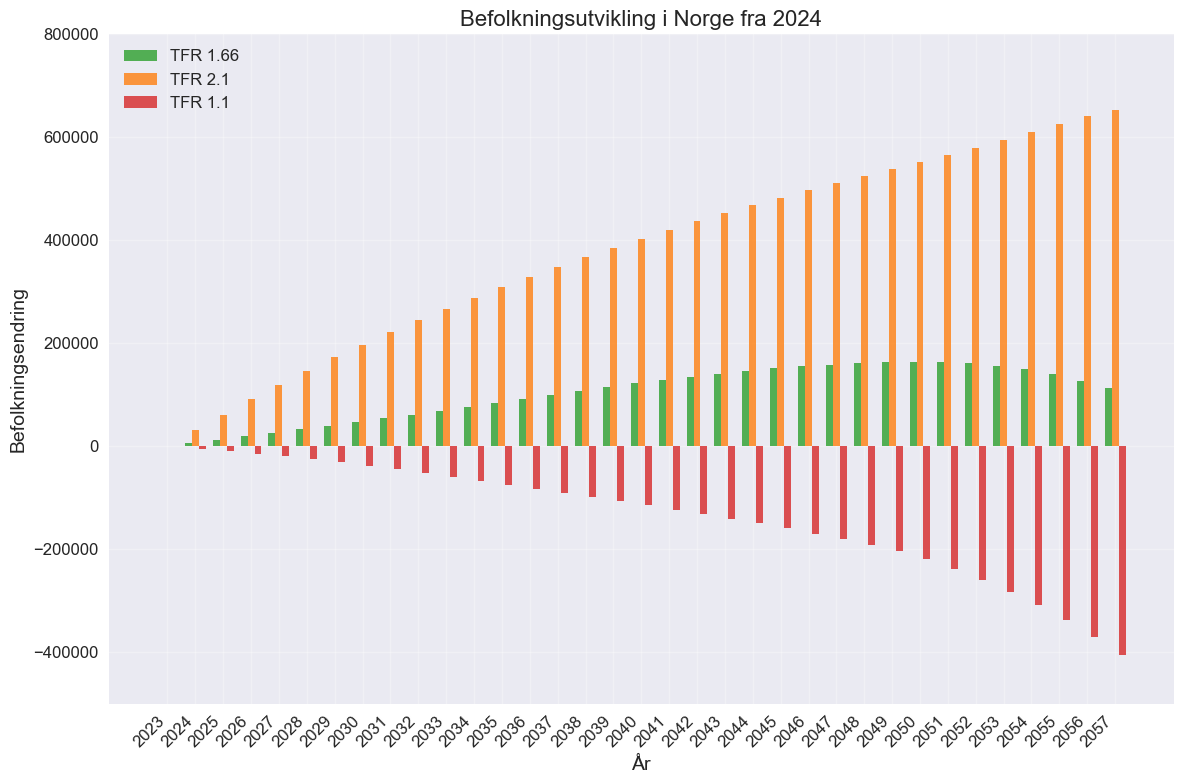

In [63]:
width = 0.25  # Width of the bars

x = np.arange(len(befolkning.år))  # the label locations

fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(x - width, befolkning["pop_1_66_endring"], width, color=colors_tfr[2], alpha=0.8, label='TFR 1.66')
ax.bar(x, befolkning["pop_2_endring"], width, color=colors_tfr[1], alpha=0.8, label='TFR 2.1')
ax.bar(x + width, befolkning["pop_1_1_endring"], width, color=colors_tfr[3], alpha=0.8, label='TFR 1.1')

ax.set_ylim(-0.5e6, 8e5)
ax.set_ylabel('Befolkningsendring')
ax.set_xlabel('År')
ax.set_xticks(x)
ax.set_xticklabels(befolkning.år, rotation=45, ha='right')
ax.set_title('Befolkningsutvikling i Norge fra 2024')
ax.legend()

plt.tight_layout()


In [64]:
pop = pd.read_csv(data / 'popfordeling_2023-2073_tfr1_66.csv').iloc[:,:93]

year_from = 2023
year_to =  2023 + 32

pop = pop[["sex","alder", f"pop_{year_from}", f"pop_{year_to}"]]
pop

,sex,alder,pop_2023,pop_2055
0,K,0,25310.0,21618.0
1,K,1,28037.0,21857.0
2,K,2,26820.0,22110.0
3,K,3,27466.0,22563.0
4,K,4,27692.0,22910.0
...,...,...,...,...
215,M,105,28.0,NaN
216,M,106,NaN,1.0
217,M,107,NaN,NaN
218,M,108,NaN,NaN


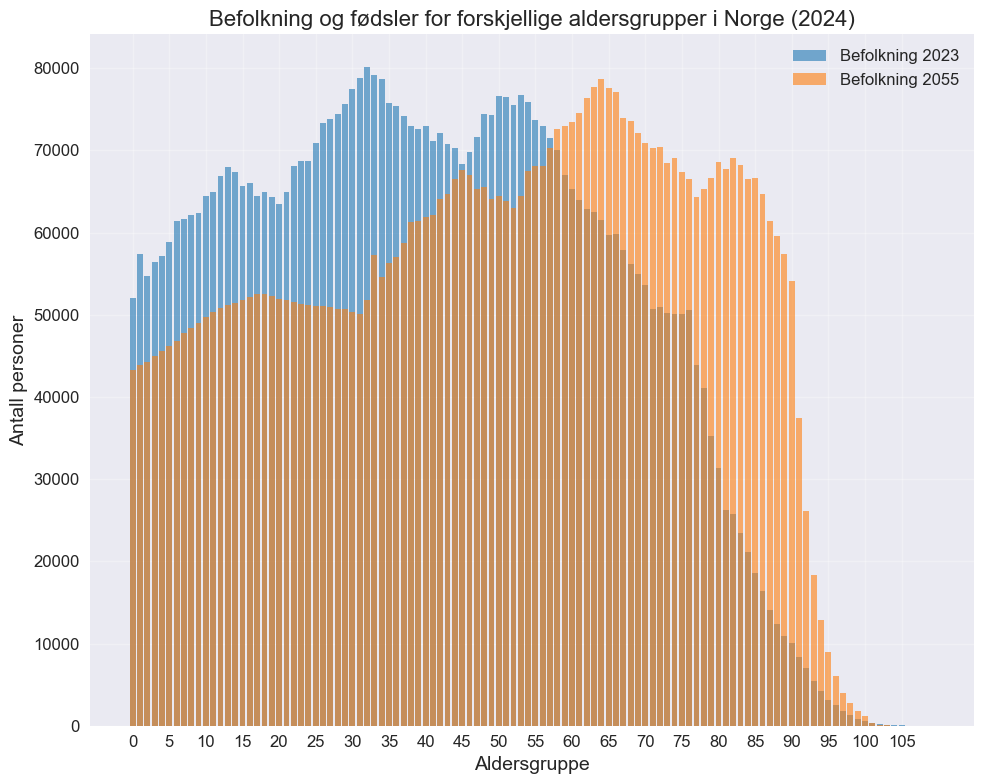

In [65]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 8))
pop_total = pop.groupby("alder")[["pop_2023", "pop_2055"]].sum().reset_index()

ax.bar(pop_total.index, pop_total[f"pop_{year_from}"], color=colors_tfr[0], alpha=0.6, label='Befolkning 2023')
ax.bar(pop_total.index, pop_total[f"pop_{year_to}"], color=colors_tfr[1], alpha=0.6, label='Befolkning 2055')

ax.set_ylabel('Antall personer')
ax.set_xlabel('Aldersgruppe')
ax.set_title('Befolkning og fødsler for forskjellige aldersgrupper i Norge (2024)')
ax.legend()

# Customizing the x-axis
ax.set_xticks(range(0, len(pop_total.index), 5))
ax.set_xticklabels(range(0, len(pop_total.index), 5))

plt.tight_layout()


In [74]:
import altair as alt
import pandas as pd
from pathlib import Path

# Load data
pop = pd.read_csv(data / 'popfordeling_2023-2073_tfr1_66.csv').iloc[:,:93]

# Create age bins (10-year intervals)
bins = list(range(0, 110, 10))
labels = [f"{i}-{i+9}" for i in range(0, 100, 10)] 
pop['alder_bins'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
grouped_data = pop.groupby("alder_bins", observed=False)[["pop_2023", "pop_2058"]].sum().reset_index()

# 1. Dumbbell Plot
melted_data = grouped_data.melt(id_vars=['alder_bins'], var_name='year', value_name='population')
melted_data = melted_data.loc[lambda x: x['alder_bins'] != '100+']
age_order = labels 

In [75]:
melted_data["year"] = melted_data["year"].str.replace("pop_", "")

In [76]:
# 3. Difference Chart
grouped_data['diff'] = grouped_data['pop_2058'] - grouped_data['pop_2023']
grouped_data['change_type'] = grouped_data['diff'].apply(lambda x: 'Økning' if x > 0 else 'Reduksjon')

diff_chart = alt.Chart(grouped_data).mark_bar().encode(
    x=alt.X('diff:Q', title='Endring i befolkning (2023 - 2058)'),
    y=alt.Y('alder_bins:N', sort=age_order, title='Aldersgrupper'),
    color=alt.Color('change_type:N', scale=alt.Scale(domain=['Økning', 'Reduksjon'], range=[colors_tfr[1], colors_tfr[0]]), title='Endringstype'),
    tooltip=['alder_bins', 'diff']
).properties(
    title='Netto befolkningsendring per aldersgruppe',
    width=400
).interactive()

# Display both
(diff_chart)

alt.Chart(...)

In [79]:
labels

['0-9',
 '10-19',
 '20-29',
 '30-39',
 '40-49',
 '50-59',
 '60-69',
 '70-79',
 '80-89',
 '90-99']

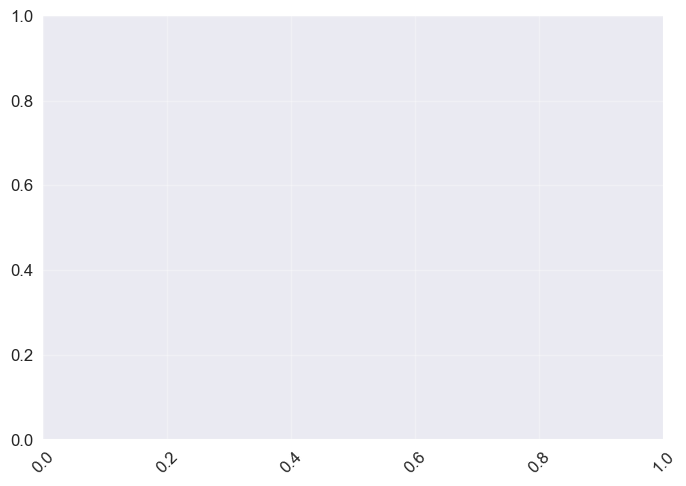

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = [colors_tfr[1] if x > 0 else colors_tfr[0] for x in grouped_data['diff']]

ax.bar(labels, grouped_data['diff'], color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=0.8)  # Add a zero line

ax.set_ylabel('Netto endring')
ax.set_xlabel('Aldersgruppe')
ax.set_title('Netto befolkningsendring (2023 - 2058)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)

plt.tight_layout()
plt.show()

In [70]:
import altair as alt
import pandas as pd
from pathlib import Path

# Load data
data_path = Path("data") / "popfordeling_2023-2073_tfr1_66.csv"
pop = pd.read_csv(data_path)

# Create age groups
bins = [0, 20, 65, np.inf]
labels = ['0-19', '20-64', '65+']
pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
cols = [f"pop_{year}" for year in range(2023, 2059)]
grouped_data = pop.groupby("age_group", observed=False)[cols].sum().reset_index()

# Calculate difference from 2023 for each year
for year in range(2024, 2059):
    grouped_data[f"diff_{year}"] = grouped_data[f"pop_{year}"] - grouped_data["pop_2023"]

# Melt for plotting
diff_cols = [f"diff_{year}" for year in range(2024, 2059)]
melted_data = grouped_data.melt(id_vars=['age_group'], value_vars=diff_cols, var_name='year', value_name='diff')
melted_data['year'] = melted_data['year'].str.replace("diff_", "").astype(int)

# Calculate support ratio (working-age / dependents)
support_ratios = []
for year in range(2024, 2059):
    working = grouped_data.loc[grouped_data['age_group'] == '20-64', f'pop_{year}'].values[0]
    young = grouped_data.loc[grouped_data['age_group'] == '0-19', f'pop_{year}'].values[0]
    old = grouped_data.loc[grouped_data['age_group'] == '65+', f'pop_{year}'].values[0]
    # ratio = working / (young + old) if (young + old) > 0 else 0
    ratio = working / old if old > 0 else 0
    support_ratios.append({'year': year, 'support_ratio': ratio})

support_df = pd.DataFrame(support_ratios)

In [71]:
# Load data
data_path = Path("data") / "popfordeling_2023-2073_tfr1_66.csv"
pop = pd.read_csv(data_path)

# Create age groups
bins = [0, 20, 65, np.inf]
labels = ['0-19', '20-64', '65+']
pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
cols = [f"pop_{year}" for year in range(2023, 2059)]
grouped_data = pop.groupby("age_group", observed=False)[cols].sum().reset_index()

# Calculate ratios
ratio_full_values = grouped_data.iloc[1, 1:] / (grouped_data.iloc[0, 1:] + grouped_data.iloc[2, 1:])
ratio_old_values = grouped_data.iloc[1, 1:] / grouped_data.iloc[2, 1:]

# Create DataFrame rows for ratios
ratio_full_row = pd.DataFrame([{'age_group': 'ratio_full', **ratio_full_values.to_dict()}])
ratio_old_row = pd.DataFrame([{'age_group': 'ratio_old', **ratio_old_values.to_dict()}])

# Concatenate the rows to grouped_data
grouped_data = pd.concat([grouped_data, ratio_full_row, ratio_old_row], ignore_index=True)
grouped_data

,age_group,pop_2023,pop_2024,pop_2025,pop_2026,pop_2027,pop_2028,pop_2029,pop_2030,pop_2031,...,pop_2049,pop_2050,pop_2051,pop_2052,pop_2053,pop_2054,pop_2055,pop_2056,pop_2057,pop_2058
0,0-19,1.241427e+06,1.227145e+06,1.212488e+06,1.198700e+06,1.183405e+06,1.168658e+06,1.152354e+06,1.135371e+06,1.119700e+06,...,1.015734e+06,1.010839e+06,1.005241e+06,9.988770e+05,9.915690e+05,9.837070e+05,9.750840e+05,9.657730e+05,9.559610e+05,9.460480e+05
1,20-64,3.236096e+06,3.235265e+06,3.233909e+06,3.231850e+06,3.230390e+06,3.227612e+06,3.225102e+06,3.220703e+06,3.213983e+06,...,2.917227e+06,2.896243e+06,2.874420e+06,2.851364e+06,2.828196e+06,2.802237e+06,2.775977e+06,2.749100e+06,2.723551e+06,2.699282e+06
2,65+,1.011461e+06,1.032946e+06,1.055485e+06,1.078199e+06,1.101759e+06,1.126227e+06,1.152059e+06,1.180404e+06,1.209848e+06,...,1.719128e+06,1.746057e+06,1.773547e+06,1.800496e+06,1.825953e+06,1.852552e+06,1.877622e+06,1.901427e+06,1.921996e+06,1.939208e+06
3,ratio_full,1.436421e+00,1.431476e+00,1.425903e+00,1.419409e+00,1.413636e+00,1.406437e+00,1.399533e+00,1.390767e+00,1.379659e+00,...,1.066682e+00,1.050545e+00,1.034415e+00,1.018572e+00,1.003788e+00,9.880046e-01,9.731031e-01,9.588100e-01,9.463487e-01,9.355433e-01
4,ratio_old,3.199427e+00,3.132076e+00,3.063908e+00,2.997452e+00,2.932030e+00,2.865863e+00,2.799424e+00,2.728475e+00,2.656518e+00,...,1.696923e+00,1.658733e+00,1.620718e+00,1.583655e+00,1.548888e+00,1.512636e+00,1.478454e+00,1.445809e+00,1.417043e+00,1.391951e+00


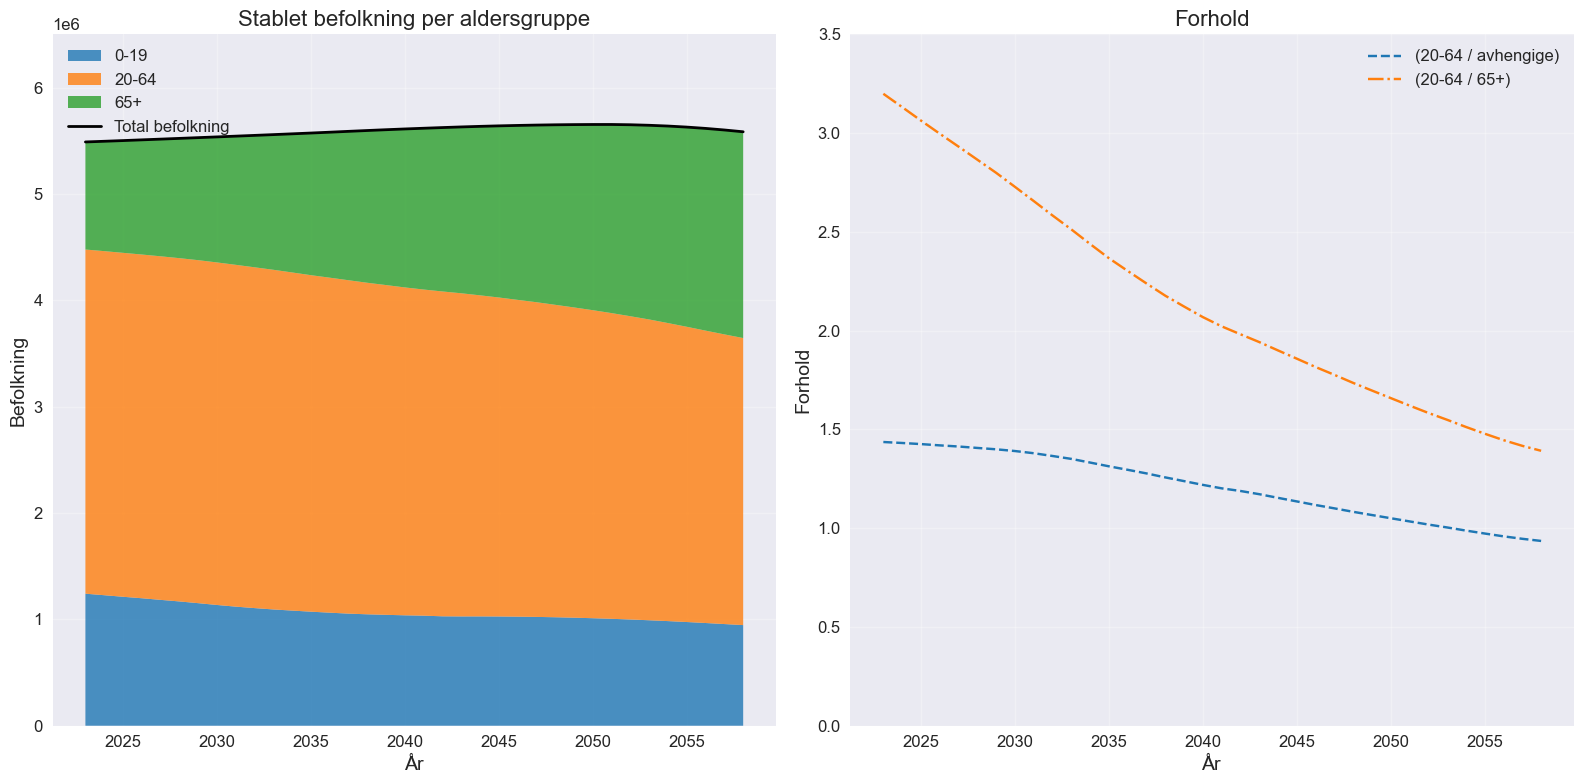

In [72]:
# Plot with subplots: stacked populations on left, ratios on right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Stacked area plot for populations with improved styling
ax1.stackplot(stack_data.index, stack_data['0-19'], stack_data['20-64'], stack_data['65+'], labels=['0-19', '20-64', '65+'], colors=colors_age, alpha=0.8)

# Add prominent line for total population
total_pop = stack_data.sum(axis=1)
ax1.plot(stack_data.index, total_pop, color='black', linewidth=2, label='Total befolkning')

ax1.set_ylabel('Befolkning')
ax1.set_xlabel('År')
ax1.set_title('Stablet befolkning per aldersgruppe')
ax1.legend(loc='upper left')
ax1.set_ylim(0, 6.5e6)

# Ratios plot
ax2.plot(ratio_full['year'], ratio_full['ratio_full'], label='(20-64 / avhengige)', color=colors_tfr[0], linestyle='--')
ax2.plot(ratio_old['year'], ratio_old['ratio_old'], label='(20-64 / 65+)', color=colors_tfr[1], linestyle='-.')
ax2.set_ylabel('Forhold')
ax2.set_xlabel('År')
ax2.set_title('Forhold')
ax2.legend(loc='upper right')
ax2.set_ylim(0,3.5)

plt.tight_layout()
plt.show()